In [1]:
import sys
sys.path.append('..')

import numpy as np
import hmm
import emission_model
import matplotlib.pyplot as plt

import numpy as np
import hmm
import emission_model
import pandas as pd
import matplotlib.pyplot as plt

from utils import Student, plot_regimes


import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'figure.dpi': 120,
    'font.family': 'serif',
    'font.size': 12,
    'mathtext.fontset': 'cm',
    'legend.fontsize': 11,
    'legend.framealpha': 0.9,
    'lines.linewidth': 1.8,
    'lines.markersize': 6,
})

In [2]:
#load data

df = pd.read_csv('../../datasets/btcusd_1-min_data.csv')


df["Date"] = pd.to_datetime(df['Timestamp'], unit='s', utc=True)
df = df.set_index('Date')

# resample five minutes frequencies

data_freq = df['Close'].resample('min').last()
data_freq = data_freq.resample('5min').last()

In [3]:
data_freq

Date
2012-01-01 10:00:00+00:00        4.58
2012-01-01 10:05:00+00:00        4.58
2012-01-01 10:10:00+00:00        4.58
2012-01-01 10:15:00+00:00        4.58
2012-01-01 10:20:00+00:00        4.58
                               ...   
2026-06-03 00:05:00+00:00    66750.00
2026-06-03 00:10:00+00:00    66724.28
2026-06-03 00:15:00+00:00    66991.32
2026-06-03 00:20:00+00:00    66788.00
2026-06-03 00:25:00+00:00    66683.98
Freq: 5min, Name: Close, Length: 1516782, dtype: float64

In [4]:
# Analyze first semester of 2021 (2 minute-resolution) 

data_freq_2021 = data_freq[data_freq.index >= '2021-12-31']
data_freq_2021 = data_freq_2021[data_freq_2021.index <= '2023-02-01']
returns = np.log((data_freq_2021.shift(-1)[:-1] / data_freq_2021[:-1]))

In [5]:
returns.isna().any()

np.False_

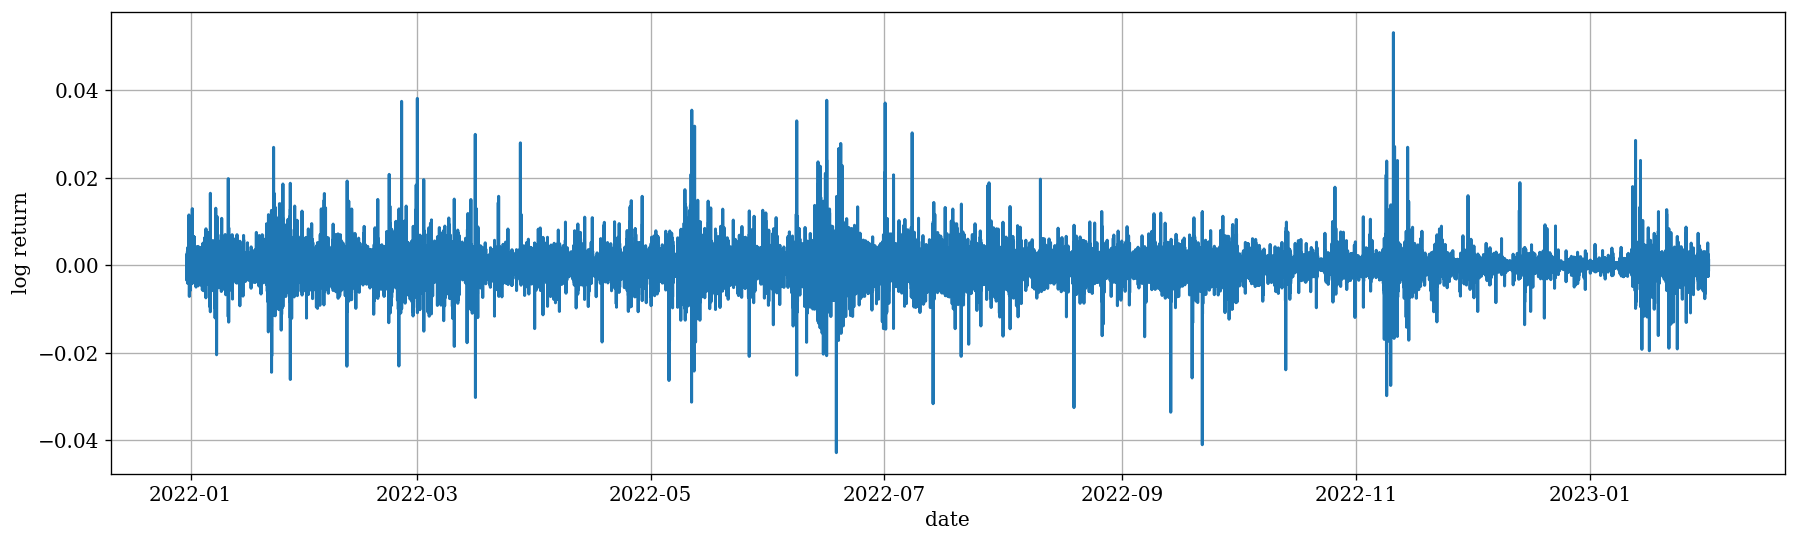

In [6]:
plt.figure(figsize = (18, 5))
plt.plot(returns)
plt.xlabel('date')
plt.ylabel('log return')   
plt.grid(True)

In [25]:
# Analyze  2022 (5 minute-resolution) 

data_freq_2021 = data_freq[data_freq.index >= '2022-12-31']
data_freq_2021 = data_freq_2021[data_freq_2021.index <= '2024-02-01']
returns = np.log((data_freq_2021.shift(-1)[:-1] / data_freq_2021[:-1]))

# rolling sigma : 24 hours to scale returns ( group 12*24=288 )

N = int(288)
L = np.array(returns).shape[0]

#train-test split. Train: first 80% times, Test: last 20% (assuming stationarity)

init_train = N
final_test = L-1 - N
final_train = init_test = int(N + (final_test - init_train) *4 / 5) 

data_train = np.array(returns)[init_train:final_train+1]
data_test = np.array(returns)[init_test:final_test]

sigma_roll_train = np.array([np.std(returns[i-N:i]) for i in range(N, data_train.shape[0]+N)])
sigma_roll_test = np.array([np.std(returns[init_test+i-N:init_test+i]) for i in range(N, data_test.shape[0]+N)])

print(data_train.shape, sigma_roll_train.shape)
print(data_test.shape, sigma_roll_test.shape)


data_train = (data_train / sigma_roll_train).reshape((-1, data_train.shape[0]))
data_test = (data_test / sigma_roll_test).reshape((-1, data_test.shape[0]))

(91008,) (91008,)
(22752,) (22752,)


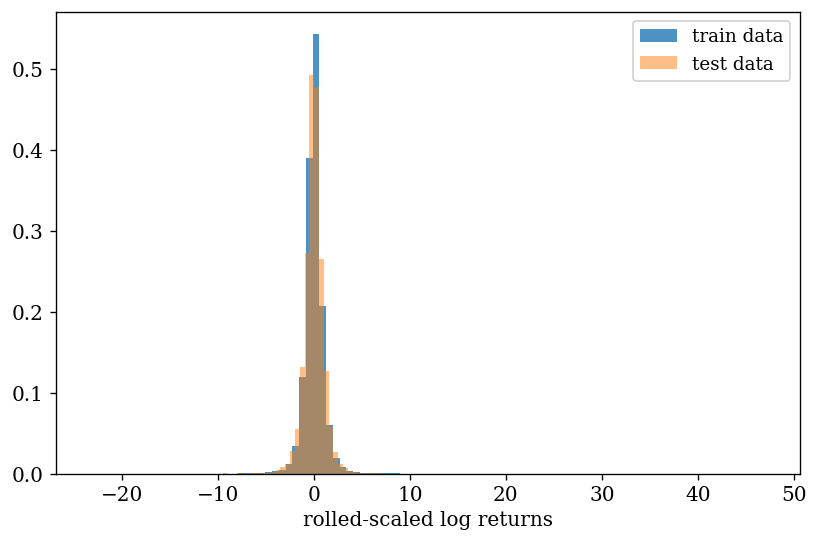

In [26]:
#plt.hist(returns, bins=100, density=True, label='full data')
plt.hist(data_train[0, :], bins=100, density=True, alpha=0.8, label ='train data')
plt.hist(data_test[0, :], bins=40, density=True, alpha=0.5, label ='test data')
plt.xlabel('rolled-scaled log returns')
plt.legend()


In [27]:
# Gaussian baseline of train data

mu = np.mean(data_train[0, :])
sigma = np.std(data_train[0, :])

mu_test = np.mean(data_test[0, :])
sigma_test = np.std(data_test[0, :])

from scipy.stats import norm

train_baseline_ll = np.mean(norm.logpdf(data_train[0, :], loc=mu, scale=sigma))
test_baseline_ll = np.mean(norm.logpdf(data_test[0, :], loc=mu_test, scale=sigma_test))

print(f"Baseline train: {train_baseline_ll:.4f} nats/step")
print(f"Baseline test:  {test_baseline_ll:.4f} nats/step")


Baseline train: -1.5227 nats/step
Baseline test:  -1.4584 nats/step


In [28]:
### Training Hidden Markov model with Student's emissions and three regimes

err = []
HMM_list = []
N_cycles = 10  # number of iterations to escape local minima
final_err = []

for i in range(N_cycles):
    
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    
    params = np.array([
    [0, np.random.uniform(0.1, 1)],  # state 0
    [0, np.random.uniform(0.1, 1)],
    #[0, np.random.uniform(0.1, 1)]  # state 1
    
    ])
    
    emission = emission_model.Gaussian_Emission(2, data_train, params)
    HMM = hmm.Hmm(2, emission, pi, A=None, eps=1e-8)
    
    err.append(HMM.Baum_Welch(data_train, data_test=data_test, N_max=70))
    final_err.append(err[i][-1])
    
    HMM_list.append(HMM)

############################################################################################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration    1  |  logL =      -2.328114  |  ΔL/L = 100.000000% |  logL_test = -2.089187
Iteration    2  |  logL =      -1.411555  |  ΔL/L = -39.369155% |  logL_test = -1.399049
Iteration    3  |  logL =      -1.403687  |  ΔL/L = -0.557395% |  logL_test = -1.391066
Iteration    4  |  logL =      -1.395659  |  ΔL/L = -0.571907% |  logL_test = -1.382071
Iteration    5  |  logL =      -1.386782  |  ΔL/L = -0.636106% |  logL_test = -1.371930
Iteration    6  |  logL =      -1.376924  |  ΔL/L = -0.710803% |  logL_test = -1.360811
Iteration    7  |  logL =      -1.366188  |  ΔL/L = -0.779719% |  logL_test = -1.349058
Iteration    8  |  logL =      -1.354868  |  ΔL/L = -0.828553% |  logL_test = -1.337156
Iteration    9  |  logL =      -1.343414  |  ΔL/L = -0.8

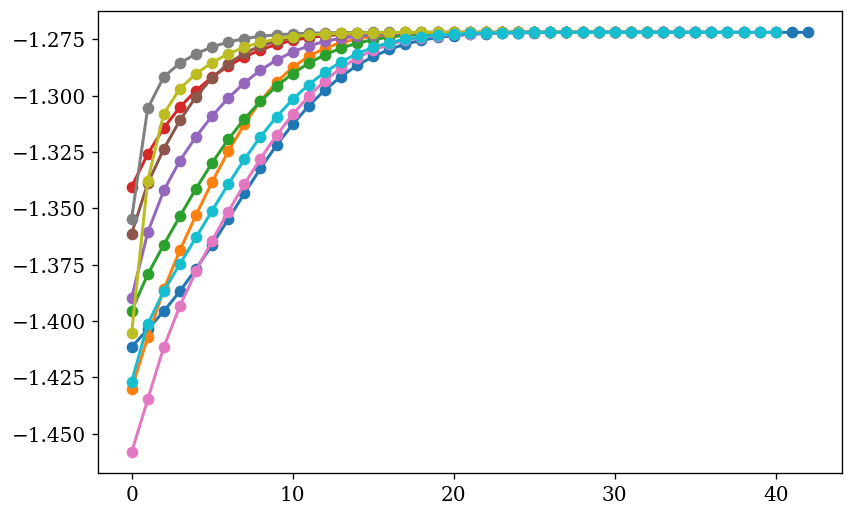

In [29]:
import matplotlib.pyplot as pltFalse

for i in range(N_cycles):
    
    plt.plot(err[i][1:], marker='o')

In [30]:
HMM = HMM_list[np.argmin(np.array(final_err))]

In [31]:
HMM.emission.params

array([[0.02248629, 2.25079733],
       [0.00378107, 0.6263363 ]])

In [32]:
# saving the HMM to file

import pickle

with open('HMM_btc_2021.pkl', 'wb') as f:
    pickle.dump(HMM, f)


In [33]:
# no need to re run the training
import pickle

with open('HMM_btc_2021.pkl', 'rb') as f:
    HMM = pickle.load(f)

Text(0.5, 1.0, 'emission probability distributions (volatility regimes)')

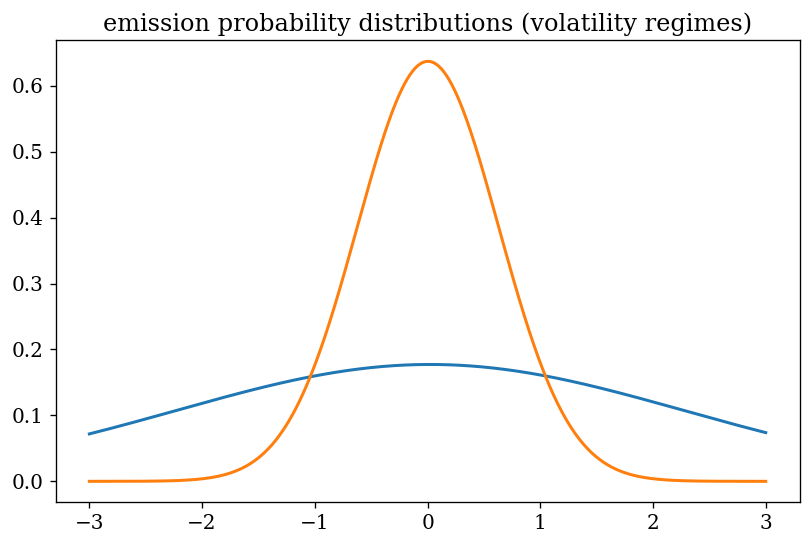

In [34]:
from utils import Student, Gaussian
x = np.linspace(-3, 3, 10000)
plt.plot(x, Gaussian(x, *HMM.emission.params[0, :]))
plt.plot(x, Gaussian(x, *HMM.emission.params[1, :]))
#plt.plot(x, Gaussian(x, *HMM.emission.params[2, :]))
plt.title('emission probability distributions (volatility regimes)')

In [35]:
print(HMM.emission.params)
print(HMM.A)

[[0.02248629 2.25079733]
 [0.00378107 0.6263363 ]]
[[0.84716689 0.15283311]
 [0.0334106  0.9665894 ]]


In [36]:
# get the best sequence of hidden states given the model parameters from training
best_seq_train = HMM.Viterbi(data_train)

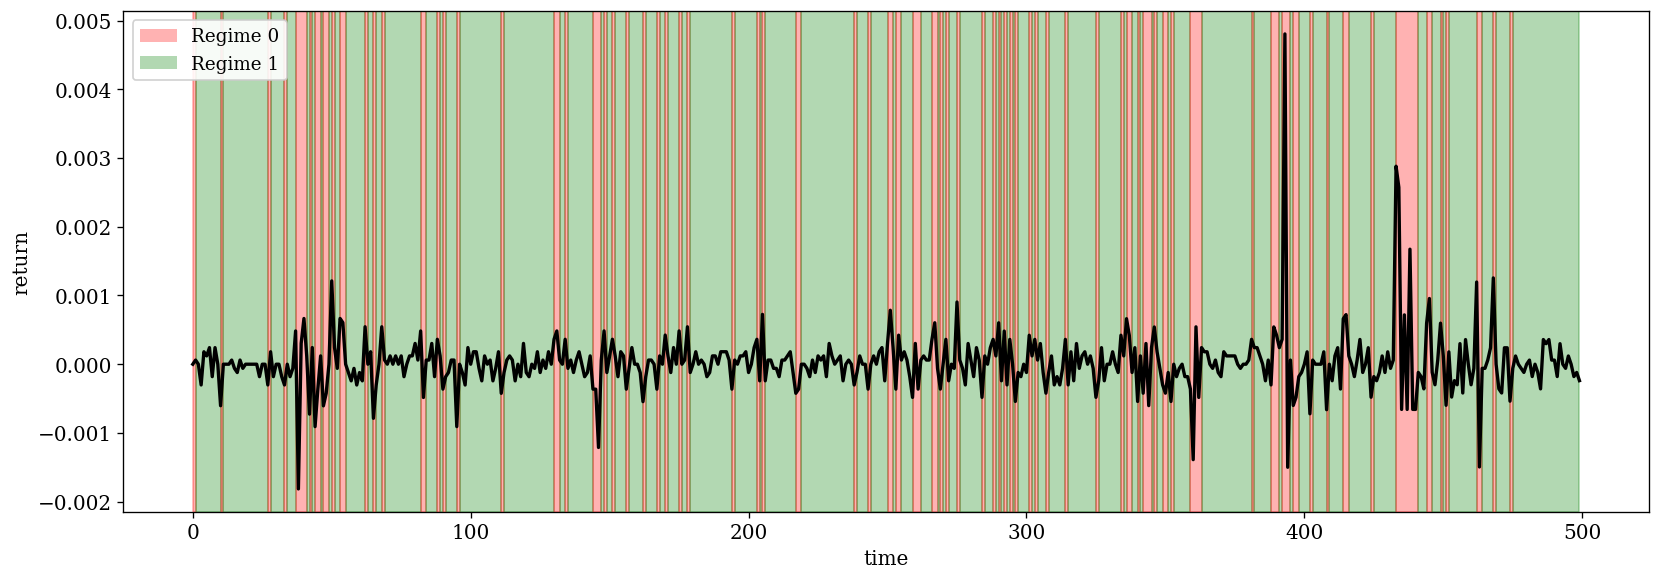

In [40]:
# plotting regimes

dates = [i for i in range(500)]

plot_regimes(dates[:], np.array(returns)[init_train:500+N], HMM.best_seqs[0, :500] , n_states=2, colors=['red', 'green'])

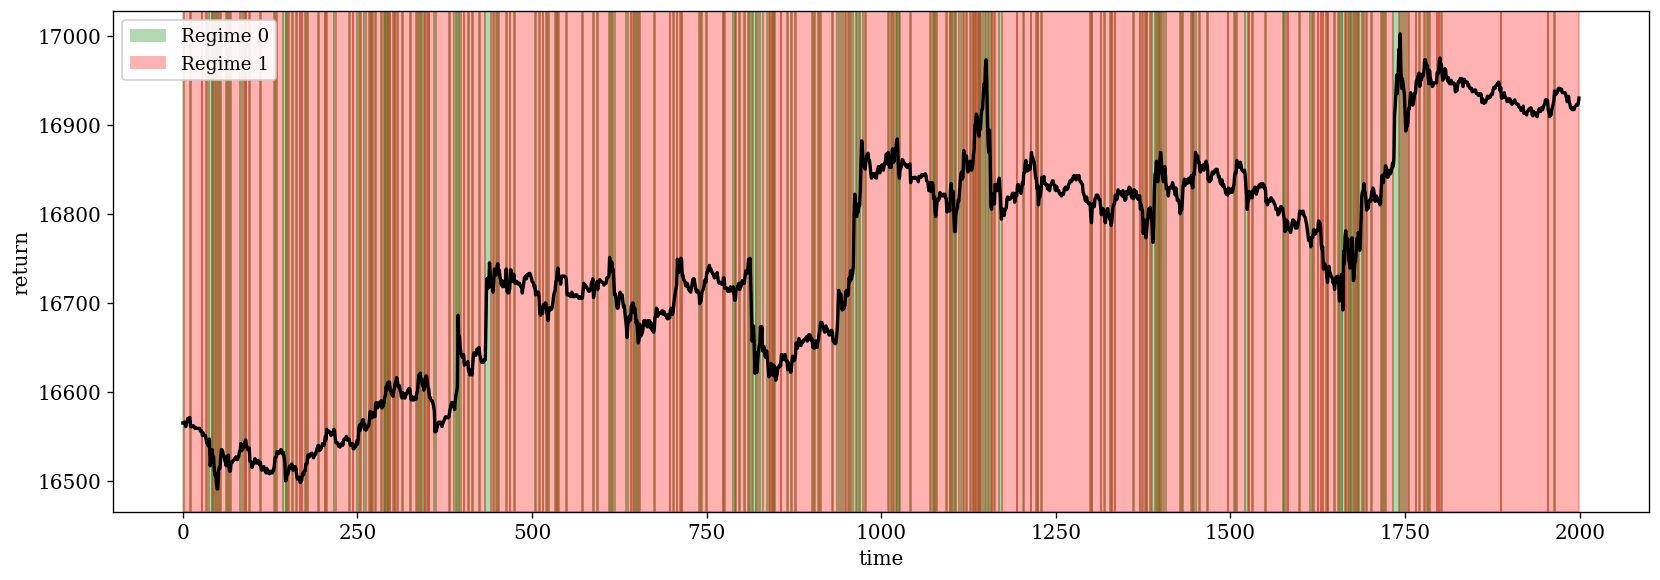

Text(0, 0.5, 'price')

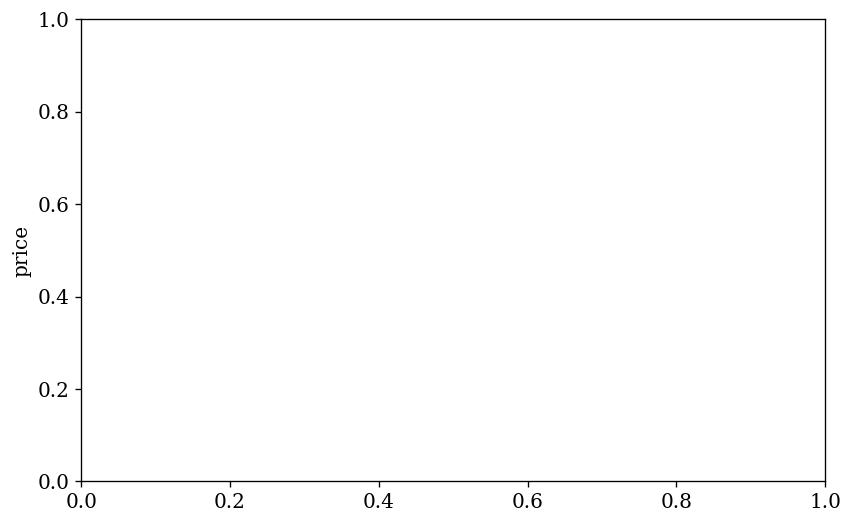

In [38]:
# plotting regimes and price 

dates = [i for i in range(2000)]

plot_regimes(dates[:], np.array(data_freq_2021)[init_train:init_train+2000], HMM.best_seqs[0, :2000] , n_states=2, colors=['green', 'red'])
plt.ylabel('price')
